# Домашнее задание № 8 : исследование случайного леса
### [Ссылка на датасет](https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars)
## EDA датасета
### Первичный осмотр данных


In [1]:
import re
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
df = pd.read_csv('ToyotaCorolla.csv')
df.shape[0] # количество строк в датасете

1436

In [2]:

missing_values = df.isnull().sum() # количество колонок с пропусками
missing_values[missing_values > 0] # колонки с пропусками

Series([], dtype: int64)

In [3]:
df.info() # информация о типах данных

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

In [4]:
df.describe() # основные статистики

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.duplicated().sum() # количество дубликатов

np.int64(0)

In [6]:
price_stats = df['Price'].describe()
price_stats

count     1436.000000
mean     10730.824513
std       3626.964585
min       4350.000000
25%       8450.000000
50%       9900.000000
75%      11950.000000
max      32500.000000
Name: Price, dtype: float64

## Матрица корреляций

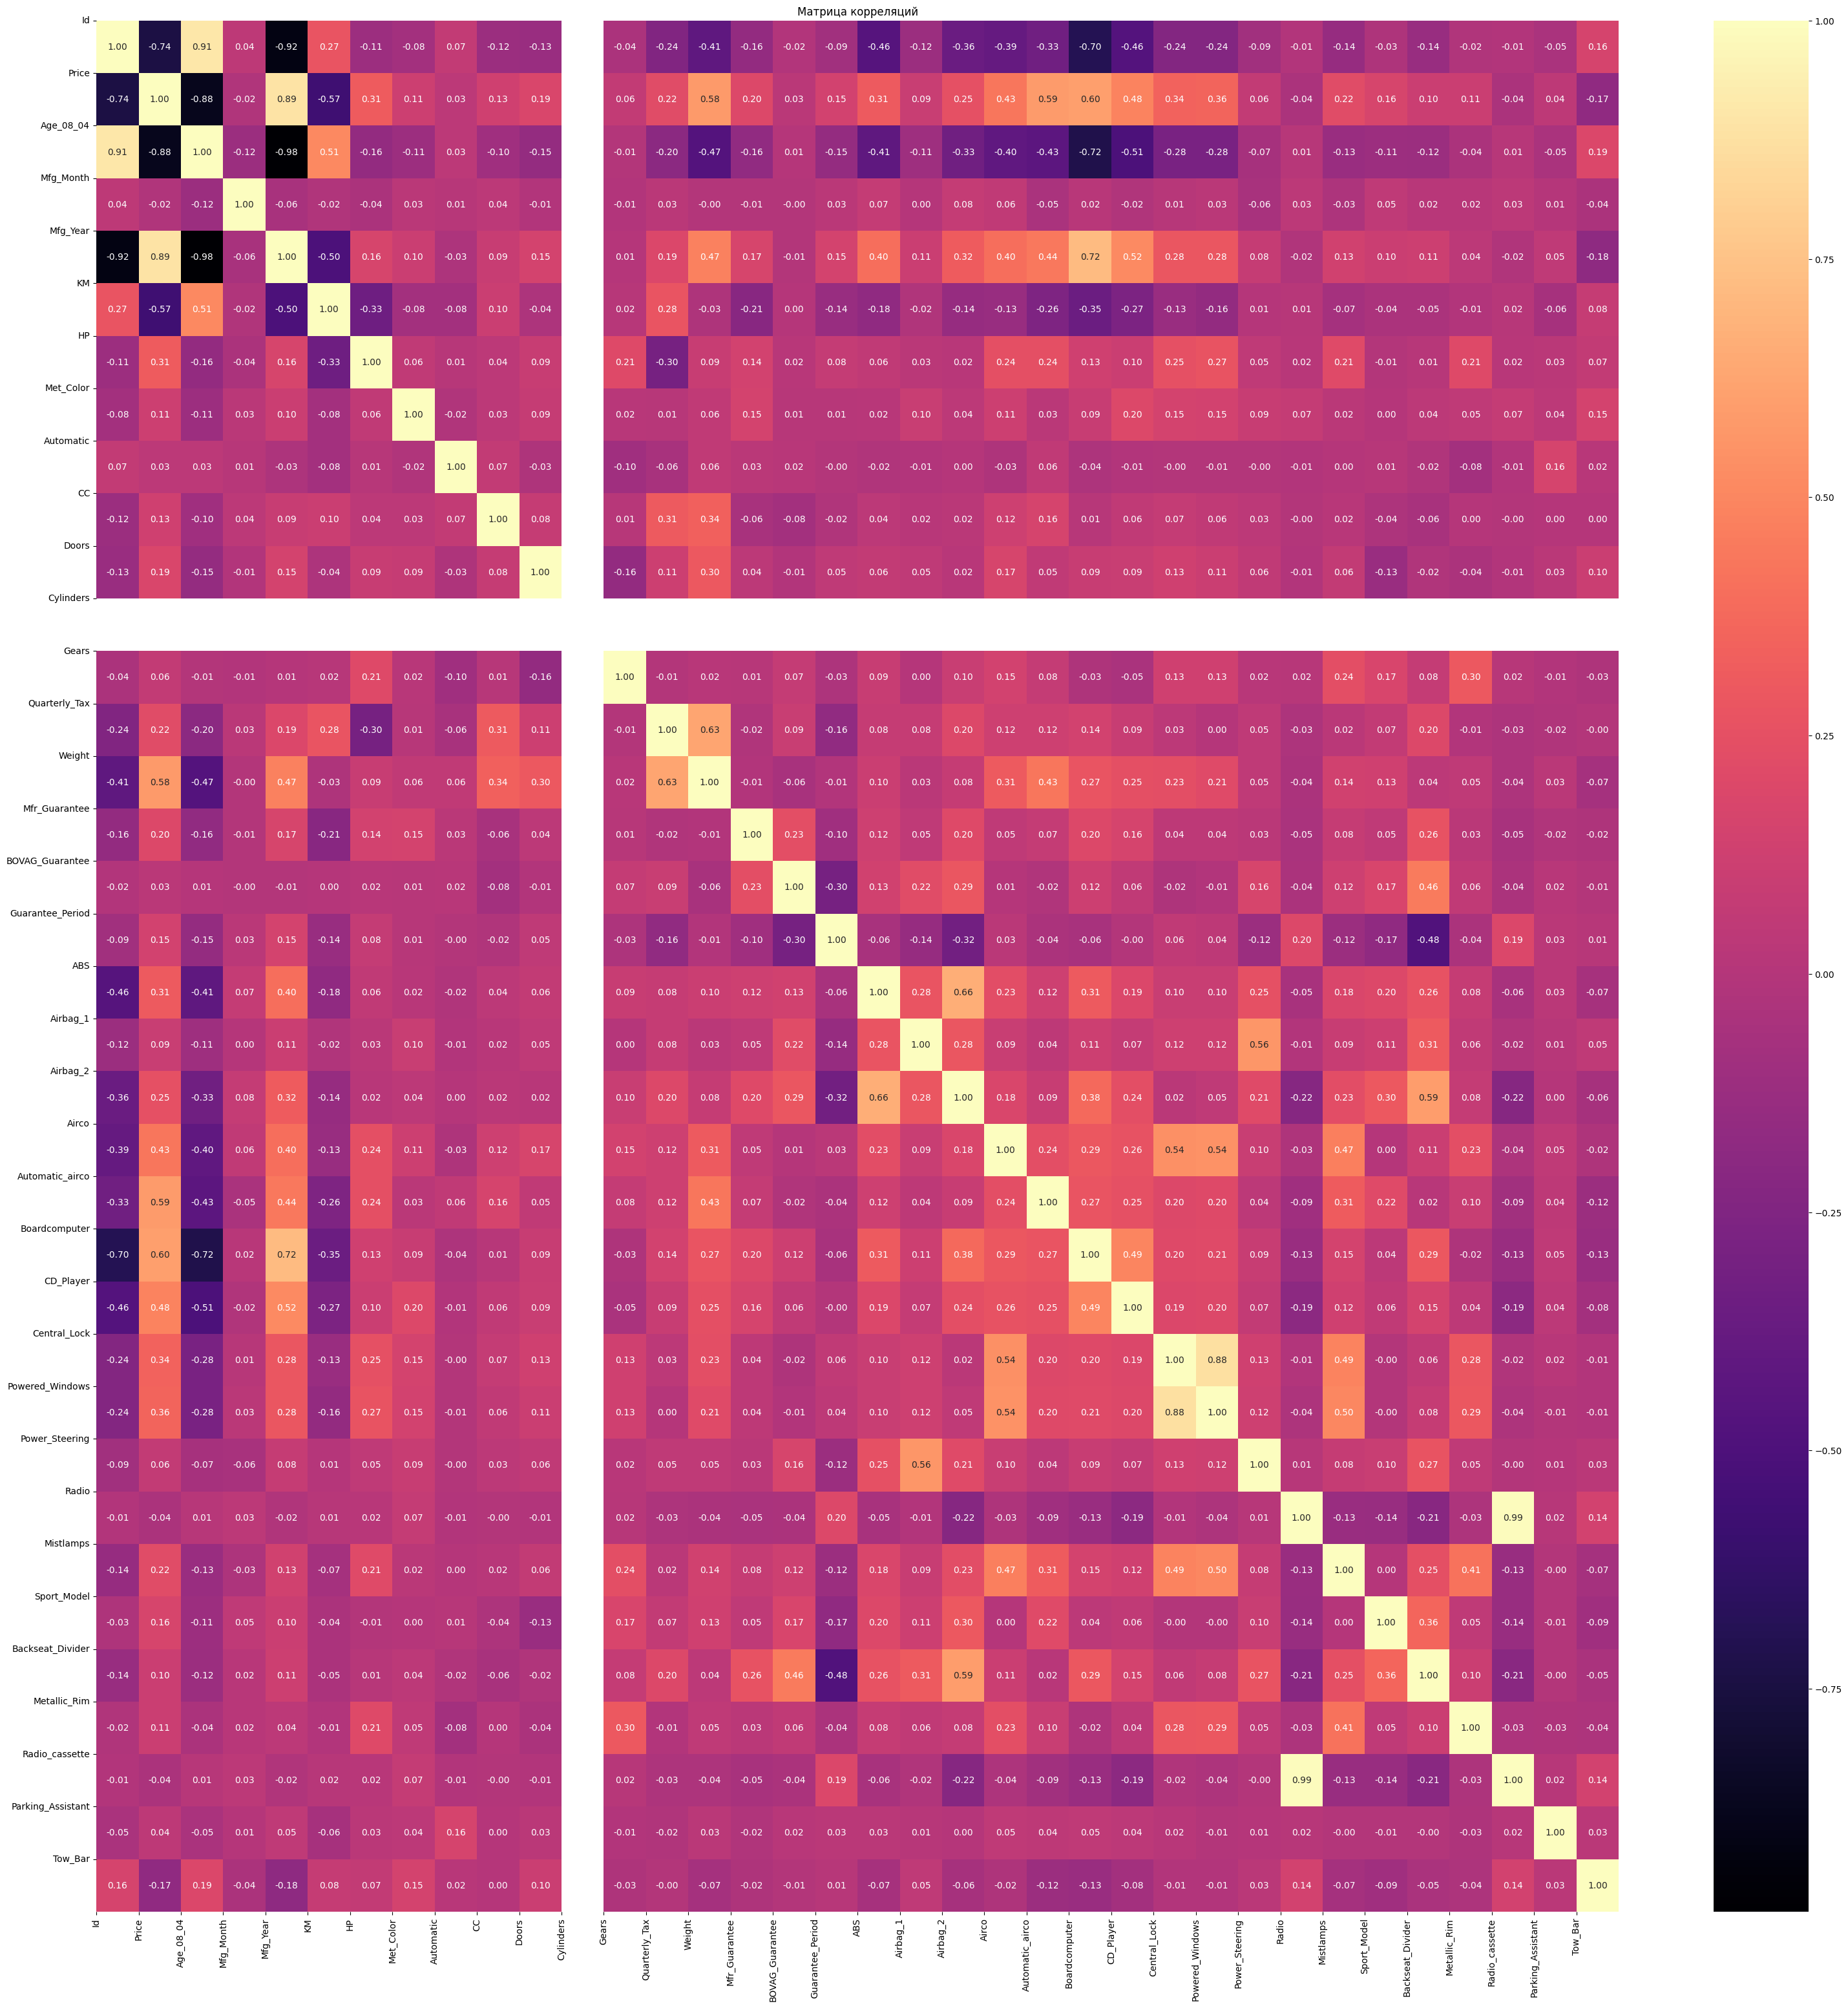

In [7]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(38, 38))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

In [8]:
# масштабируем признаки, отвечающие за производительность, и объединяем их в один
minmax_scaler = MinMaxScaler()
df['HP_norm'] = minmax_scaler.fit_transform(df[['HP']])
df['CC_norm'] = minmax_scaler.fit_transform(df[['CC']])
df['Cylinders_norm'] = minmax_scaler.fit_transform(df[['Cylinders']])
df['Perfomance'] = (df['HP_norm'] * 0.5 + df['CC_norm'] * 0.3 + df['Cylinders_norm'] * 0.2).round(3)

In [9]:
# удаляем лишние и не влияющие на прогноз признаки
df = df.drop(['HP', 'CC', 'Cylinders', 'HP_norm', 'CC_norm', 'Cylinders_norm', 'Color', 'Mfg_Month', 'Mfg_Year', 'Id'], axis=1)

In [10]:
df['Perfomance'].describe()

count    1436.000000
mean        0.137874
std         0.061944
min         0.010000
25%         0.099750
50%         0.173000
75%         0.173000
max         0.510000
Name: Perfomance, dtype: float64

In [11]:
df = df.drop(columns=['Model'])

В данных отсутствуют пропуски и дубликаты. Целевая переменная - цена (Price), ее мы и будем предсказывать. В датасете присутствуют линейно зависимые признаки Mfg_month, Mfg_year, Age_08_04 - оставил Age_08_04. Так же есть признаки HP, CC, Cylinders, которые объединил в один - Performance.

## Кодировка признаков

In [12]:
df_enc = pd.get_dummies(df, columns=['Fuel_Type'], dtype=int)
df_enc.head(10)

,Price,Age_08_04,KM,Met_Color,Automatic,Doors,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,...,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Perfomance,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,1,0,3,5,210,1165,0,...,0,1,0,0,0,0,0.100,0,1,0
1,13750,23,72937,1,0,3,5,210,1165,0,...,0,1,0,0,0,0,0.100,0,1,0
2,13950,24,41711,1,0,3,5,210,1165,1,...,0,1,0,0,0,0,0.100,0,1,0
3,14950,26,48000,0,0,3,5,210,1165,1,...,0,1,0,0,0,0,0.100,0,1,0
4,13750,30,38500,0,0,3,5,210,1170,1,...,0,1,0,0,0,0,0.100,0,1,0
5,12950,32,61000,0,0,3,5,210,1170,0,...,0,1,0,0,0,0,0.100,0,1,0
6,16900,27,94612,1,0,3,5,210,1245,0,...,1,1,0,0,0,0,0.100,0,1,0
7,18600,30,75889,1,0,3,5,210,1245,1,...,0,1,0,0,0,0,0.100,0,1,0
8,21500,27,19700,0,0,3,5,100,1185,0,...,0,0,1,1,0,0,0.510,0,0,1
9,12950,23,71138,0,0,3,5,185,1105,0,...,0,1,0,0,0,0,0.012,0,1,0


## Масштабирование и разделение данных

In [13]:
scaler = StandardScaler()
features = df_enc.columns.values.tolist()[1:] # все признаки (за исключением цены)
X = df_enc[features].values
Y = df_enc['Price'].values

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Обучение модели

In [14]:
model = LinearRegression()
model.fit(X_train, Y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print(f"R2 на тренировочной выборке: {r2_score(Y_train, train_pred)}")
print(f"R2 на тестовой выборке: {r2_score(Y_test, test_pred)}")

R2 на тренировочной выборке: 0.9035767890228337
R2 на тестовой выборке: 0.8803665361963079


## Подбор гиперпараметров и регуляризация

In [15]:
ridge = Ridge()
alpha_params = [0.01, 0.1, 1 ,5, 10, 100, 1000]
# alpha_params = [el /1.5  for el in alpha_params]
ridge_params = {'alpha' : alpha_params}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=7)
ridge_grid.fit(X_train, Y_train)
best_ridge = ridge_grid.best_estimator_
print(f'Лучший параметр alpha для L1-регуляризатора: {ridge_grid.best_params_['alpha']}')

best_ridge_train_pred = best_ridge.predict(X_train)
best_ridge_test_pred = best_ridge.predict(X_test)

print(f"R2 на тренировочной выборке: {r2_score(Y_train, best_ridge_train_pred)}")
print(f"R2 на тестовой выборке: {r2_score(Y_test, best_ridge_test_pred)}")

Лучший параметр alpha для L1-регуляризатора: 5
R2 на тренировочной выборке: 0.9030289462112188
R2 на тестовой выборке: 0.8778556036061903


In [16]:
lasso = Lasso()
lasso_params ={ 'alpha' : alpha_params}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5)
lasso_grid.fit(X_train, Y_train)
best_lasso = lasso_grid.best_estimator_
print(f'Лучший параметр alpha для L2-регуляризатора: {lasso_grid.best_params_['alpha']}')
best_lasso_train_pred = best_lasso.predict(X_train)
best_lasso_test_pred = best_lasso.predict(X_test)

print(f"R2 на тренировочной выборке: {r2_score(Y_train, best_lasso_train_pred)}")
print(f"R2 на тестовой выборке: {r2_score(Y_test, best_lasso_test_pred)}")

d:\ML\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.980e+08, tolerance: 1.213e+06
  model = cd_fast.enet_coordinate_descent(
d:\ML\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.437e+08, tolerance: 1.213e+06
  model = cd_fast.enet_coordinate_descent(


Лучший параметр alpha для L2-регуляризатора: 5
R2 на тренировочной выборке: 0.9024753382511657
R2 на тестовой выборке: 0.878044113814765


## Обработка данных для случайного леса

In [ ]:
categorial_columns = df.select_dtypes(include=['str']).columns
print(categorial_columns)
encoder = OrdinalEncoder()
df[categorial_columns] = encoder.fit_transform(df[categorial_columns])
df[categorial_columns] = df[categorial_columns].astype(int)

Index([], dtype='str')


,Price,Age_08_04,KM,Fuel_Type,Met_Color,Automatic,Doors,Gears,Quarterly_Tax,Weight,...,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Perfomance
0,13500,23,46986,1,1,0,3,5,210,1165,...,1,0,0,0,1,0,0,0,0,0.100
1,13750,23,72937,1,1,0,3,5,210,1165,...,1,0,0,0,1,0,0,0,0,0.100
2,13950,24,41711,1,1,0,3,5,210,1165,...,1,0,0,0,1,0,0,0,0,0.100
3,14950,26,48000,1,0,0,3,5,210,1165,...,1,0,0,0,1,0,0,0,0,0.100
4,13750,30,38500,1,0,0,3,5,210,1170,...,1,0,1,0,1,0,0,0,0,0.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,1,0,3,5,69,1025,...,1,0,1,1,1,0,0,0,0,0.069
1432,10845,72,19000,2,0,0,3,5,69,1015,...,1,0,0,1,1,0,0,0,0,0.069
1433,8500,71,17016,2,0,0,3,5,69,1015,...,1,0,0,0,1,0,0,0,0,0.069
1434,7250,70,16916,2,1,0,3,5,69,1015,...,0,0,0,0,1,0,0,0,0,0.069


Для обучения случайного леса я к данным применил только OrdinalEncoder, пропусков нет, к выбросам модель не чувствительна, и масштабирование признаков не требуется

## Разделение данных

In [25]:
features = df.columns.to_list()[1:]
y_rf = df['Price']
X_rf = df[features]

X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

## Обучение случайного леса

In [40]:
random_forest_model = RandomForestRegressor(max_depth=10000)
random_forest_model.fit(X_rf_train, y_rf_train)
rf_score = cross_val_score(random_forest_model, X_rf_test, y_rf_test, cv=5)
print(f'Random forest score {rf_score.max()}')

Random forest score 0.9050635377023314


## Обучение одного дерева

In [42]:
decision_tree_model = DecisionTreeRegressor(max_depth=10000)
decision_tree_model.fit(X_rf_train, y_rf_train)
tree_score = cross_val_score(decision_tree_model, X_rf_test, y_rf_test, cv=5)
print( f' 1 decision tree score {tree_score.max()}')

 1 decision tree score 0.8190887594382599


У одного решающего дерева такой же глубины, как и у случайного леса score заметно меньше, так как возникает переобучение за счет такой глубины

Время обучения случайного леса в несколько раз больше, чем одного дерева, распараллелив обучения каждого дерева в случайном лесу, можно добиться намного меньшего времени